In [38]:
# importing the packages
import numpy as np
import pandas as pd
from itertools import chain
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

In [39]:
# read the pairings.txt file
# Open the file in read mode
with open("../data/subset_pairings/subset_pairings.txt", "r") as file:
    lines = file.readlines()

# convert each line (representing a list) to an actual list
pairings = [eval(line) for line in lines]

# sort pairings based on the first element of each list
pairings.sort(key=lambda x: x[0])

In [40]:
# read the flight leg data
np_arr = pd.read_csv(
    "../data/flight_legs/data.csv",
    parse_dates=["start_time", "end_time"],
).to_numpy()

departure_time = [[np_arr[j][3] for j in i] for i in pairings]
flight_leg_id = [[np_arr[j][0] for j in i] for i in pairings]
departure_airport = [[np_arr[j][1] for j in i] for i in pairings]
destination_airport = [[np_arr[j][2] for j in i] for i in pairings]

In [84]:
# find the max and min departure time from the list of list
max_departure_time = max(list(chain(*departure_time)))
min_departure_time = min(list(chain(*departure_time)))

In [41]:
# convert to a dictionary where key is the 'sub_pair' & index +1
pairings_dict = {f"P{i+1}": pair for i, pair in enumerate(departure_time)}

In [42]:
# sort the pairing dictionary based on the first timestamp
pairings_dict = dict(sorted(pairings_dict.items(), key=lambda item: item[1][0]))
print(pairings_dict)

{'P7': [Timestamp('2023-01-01 01:00:00'), Timestamp('2023-01-01 03:00:00'), Timestamp('2023-01-01 15:00:00'), Timestamp('2023-01-01 17:00:00')], 'P15': [Timestamp('2023-01-01 01:00:00'), Timestamp('2023-01-01 03:00:00'), Timestamp('2023-01-01 15:00:00'), Timestamp('2023-01-01 17:00:00')], 'P4': [Timestamp('2023-01-01 12:00:00'), Timestamp('2023-01-01 14:00:00'), Timestamp('2023-01-02 05:00:00'), Timestamp('2023-01-02 07:00:00')], 'P12': [Timestamp('2023-01-01 12:00:00'), Timestamp('2023-01-01 14:00:00'), Timestamp('2023-01-02 05:00:00'), Timestamp('2023-01-02 07:00:00')], 'P3': [Timestamp('2023-01-01 13:00:00'), Timestamp('2023-01-01 15:00:00'), Timestamp('2023-01-02 06:00:00'), Timestamp('2023-01-02 08:00:00')], 'P11': [Timestamp('2023-01-01 13:00:00'), Timestamp('2023-01-01 15:00:00'), Timestamp('2023-01-02 06:00:00'), Timestamp('2023-01-02 08:00:00')], 'P1': [Timestamp('2023-01-01 17:00:00'), Timestamp('2023-01-01 19:00:00'), Timestamp('2023-01-02 08:00:00'), Timestamp('2023-01-02 1

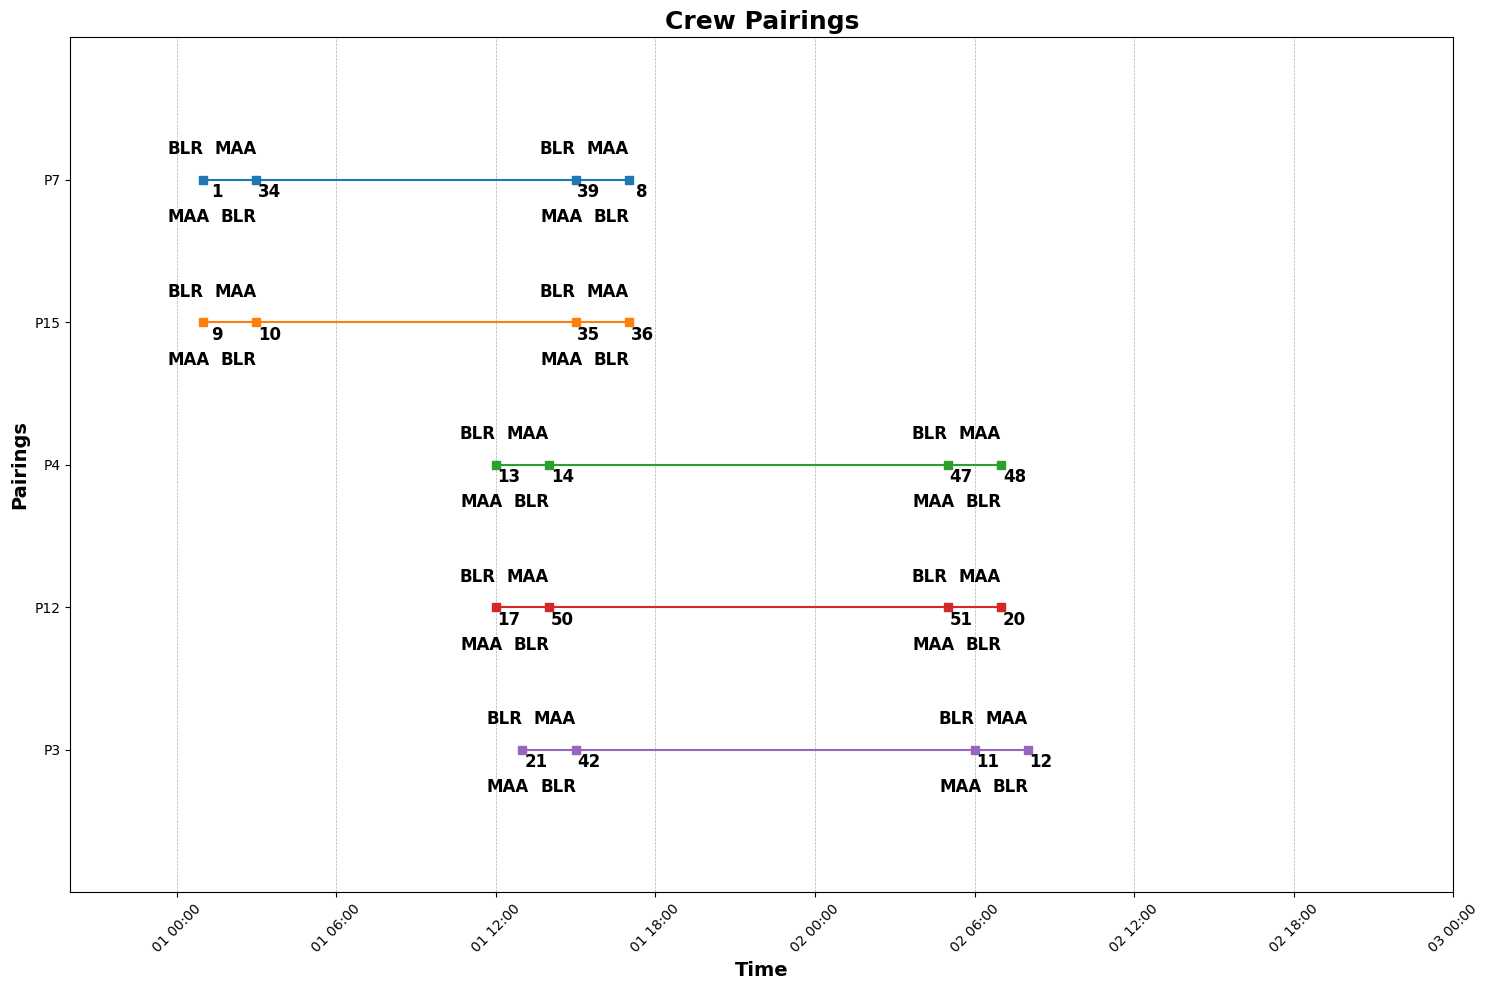

<Figure size 640x480 with 0 Axes>

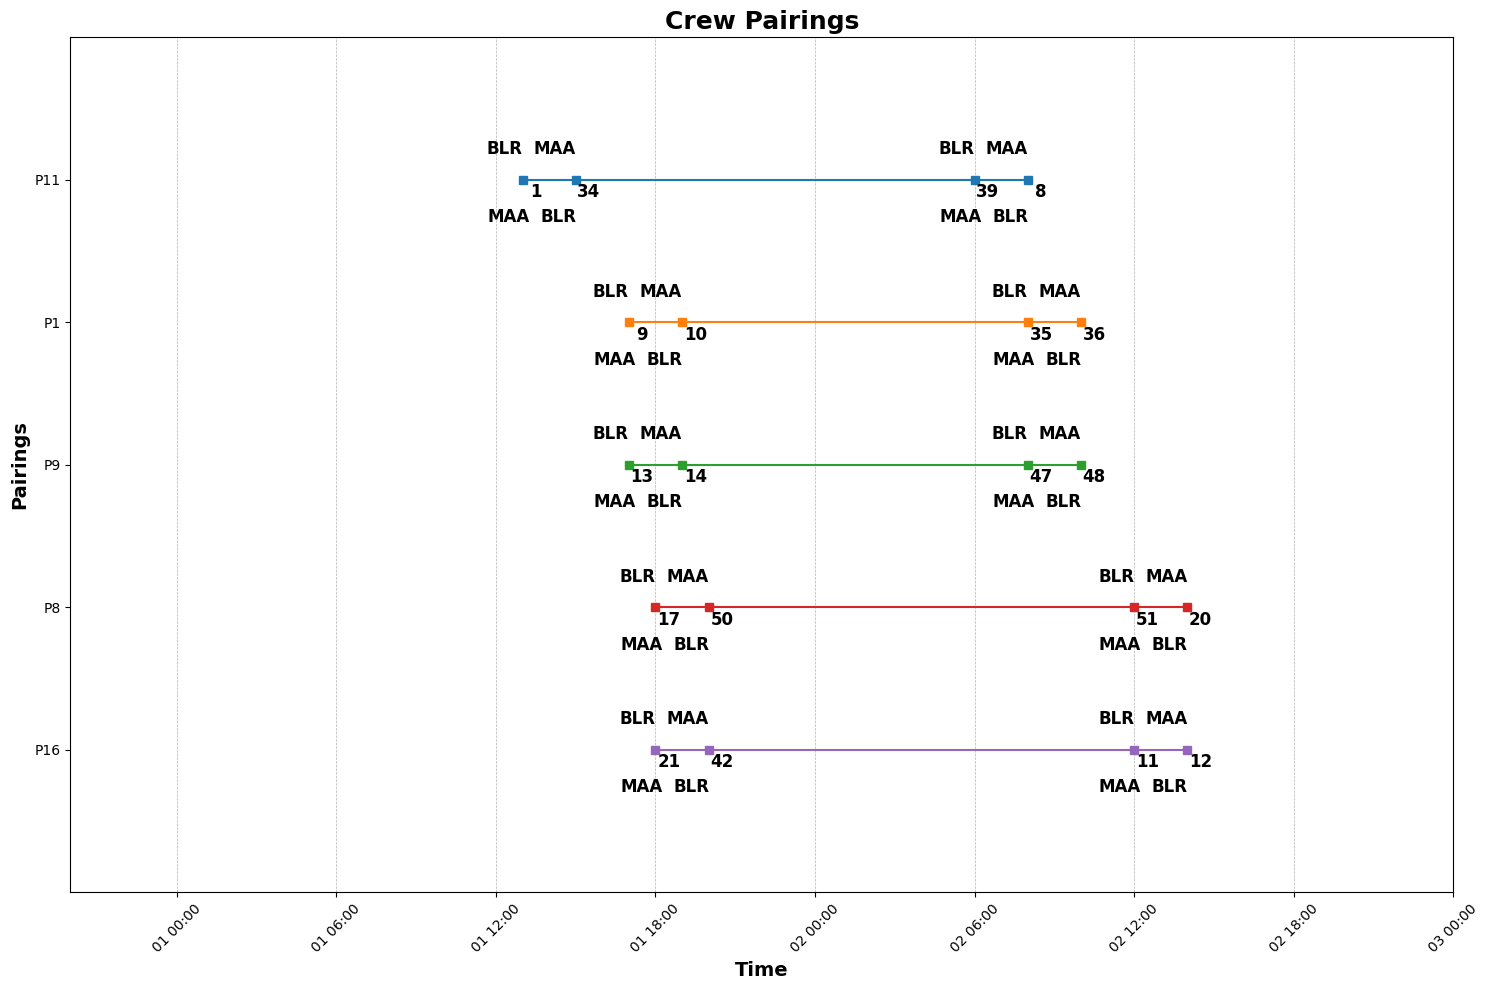

<Figure size 640x480 with 0 Axes>

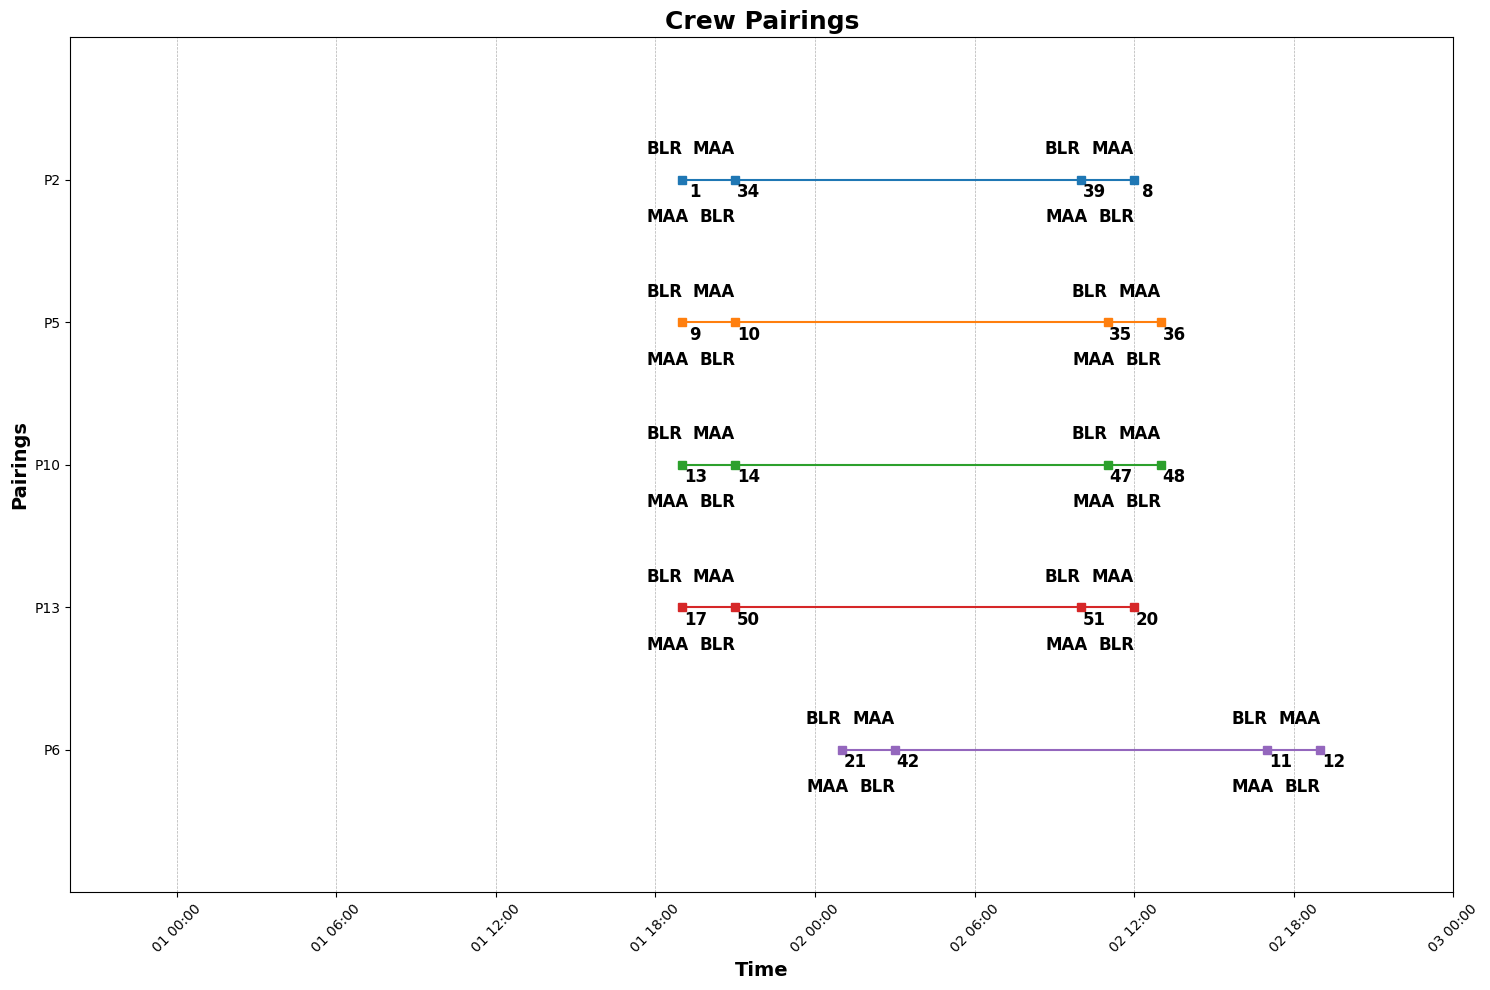

<Figure size 640x480 with 0 Axes>

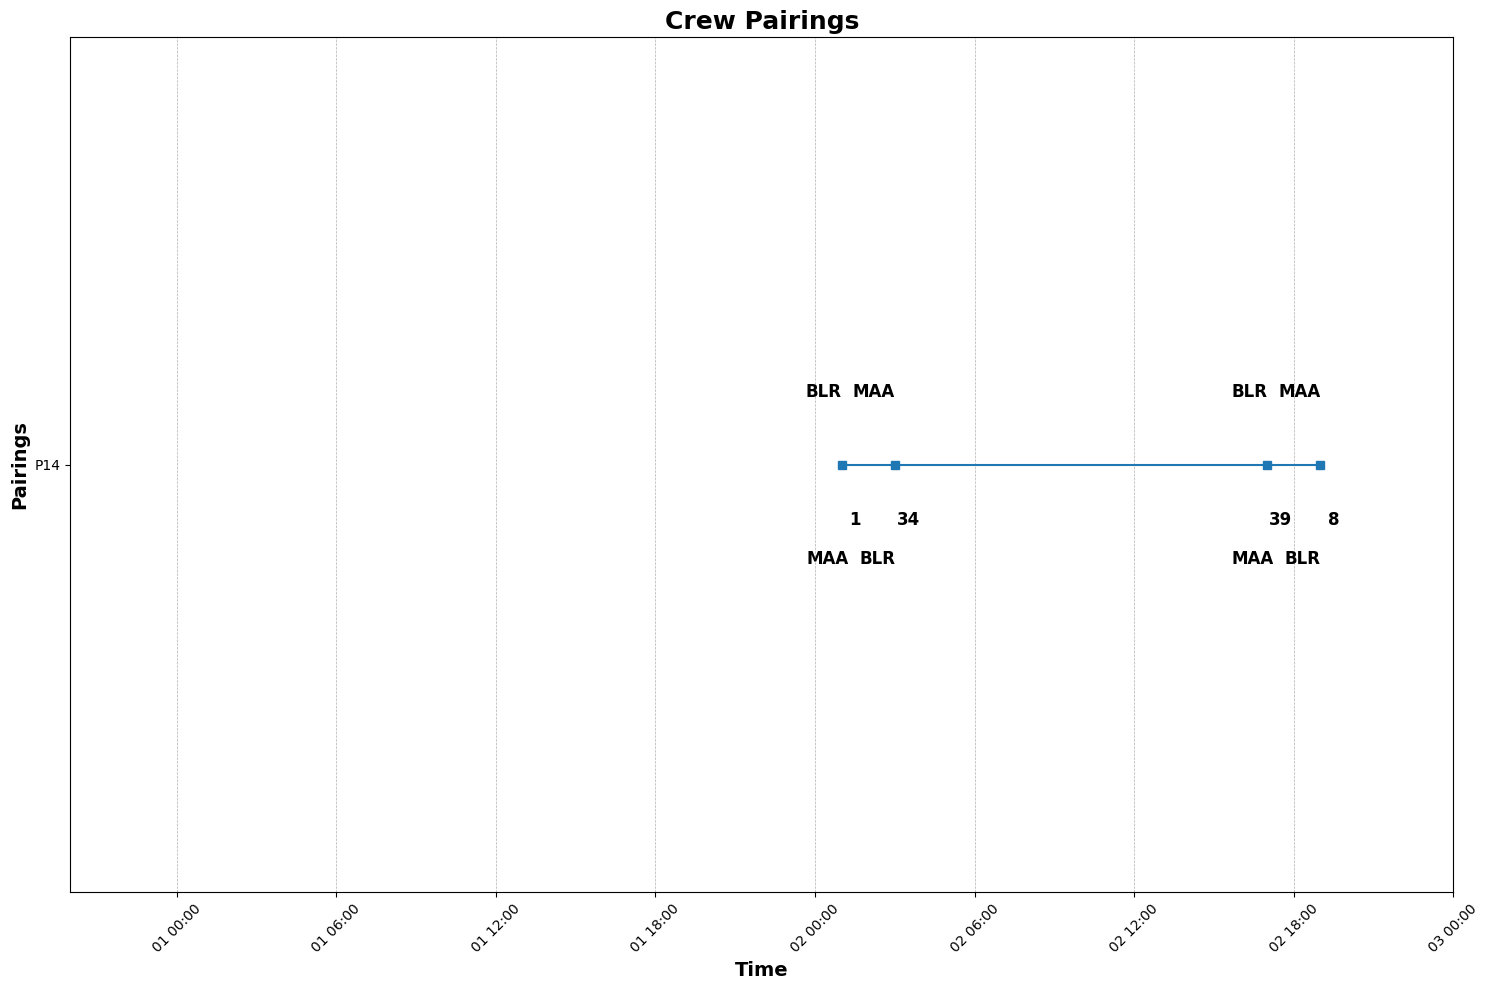

<Figure size 640x480 with 0 Axes>

In [110]:
for i in range(0, len(pairings_dict), 5):
    # get the keys
    Keys = list(pairings_dict.keys())[i : i + 5]
    # get the values
    # create a new dict with subset of keys
    pairings_dict_subset = {k: pairings_dict[k] for k in Keys}
    # Plotting


    fig = plt.figure(figsize=(15, 10))


    ax = fig.add_subplot()


    # Iterate over dictionary items and plot


    for i, (key, value) in enumerate(pairings_dict_subset.items()):


        ax.plot(value, [i] * len(value), marker="s", label=key)


        for j, (x, y) in enumerate(zip(value, [i] * len(value))):


            ax.annotate(
                f"{departure_airport[i][j]}",
                xy=(x, y),
                xytext=(x, y - 0.15),
                textcoords="data",
                ha="right",
                va="bottom",
                fontsize=12,
                fontweight="bold",
            )


            ax.annotate(
                f"{destination_airport[i][j]}",
                xy=(x, y),
                xytext=(x - pd.Timedelta(minutes=80), y + 0.2),
                textcoords="data",
                ha="left",
                va="top",
                fontsize=12,
                fontweight="bold",
            )
            ax.annotate(
                f"{flight_leg_id[i][j]}",
                xy=(x, y),
                xytext=(x + pd.Timedelta(minutes=30), y + 0.15),
                textcoords="data",
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold",
            )


    # Set y-axis ticks and labels

    ax.set_yticks(range(len(pairings_dict_subset)))

    ax.set_yticklabels(pairings_dict_subset.keys())

    # add space from the bottom and the top
    plt.ylim(bottom=-1, top=len(pairings_dict_subset))
    plt.xlim(
        min_departure_time - pd.Timedelta(hours=5),
        max_departure_time + pd.Timedelta(hours=5),
    )


    # Set x-axis date format

    date_format = DateFormatter("%d %H:%M")

    ax.xaxis.set_major_formatter(date_format)

    plt.xticks(rotation=45)


    # add  vertical grid lines only for the days
    ax.xaxis.grid(True, which="major", linestyle="--", linewidth=0.5)

    # plot in reverse order
    ax.invert_yaxis()


    # Set labels and title

    plt.xlabel("Time", fontweight="bold", fontsize=14)

    plt.ylabel("Pairings", fontweight="bold", fontsize=14)

    plt.title("Crew Pairings", fontweight="bold", fontsize=18)


    # Show plot

    plt.tight_layout()

    plt.show()
    plt.savefig(f"../data/subset_pairings/network_plot{i}.png")